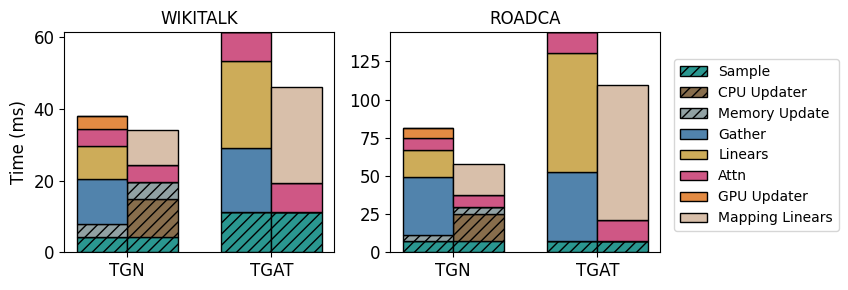

In [1]:
import yaml
import matplotlib.pyplot as plt
import numpy as np

# 读取 YAML 文件
with open("breakdown.yaml", "r") as file:
    data = yaml.safe_load(file)

# 颜色设置
colors = ["#2A9790", "#876D4C", "#91A1A3", "#5183AC", "#CDAC59", "#CF5785", "#E38B43", "#D8BFAA", "#C8755E"]

# 解析数据
datasets = ["WIKITALK", "ROADCA"]  # 数据集
methods = ["TGN", "TGAT"]
models = ["TGL", "UNITY"]

# 获取所有的成分类别（去重排序）
preferred_order = [
    "Sample", "CPU Updater", "Memory Update", "Gather", "Linears", "Attn", "GPU Updater", "Mapping Linears"
]

# 获取所有的成分类别，并根据preferred_order进行排序
all_components = sorted({
    component
    for dataset in datasets
    for method in methods
    for model in models
    if model in data[dataset].get(method, {})
    for component in data[dataset][method][model]
}, key=lambda x: preferred_order.index(x) if x in preferred_order else len(preferred_order))

num_components = len(all_components)

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=False)

# 存储 legend 显示的句柄
legend_handles = []

# 定义需要加阴影的成分类别
hatch_components = ["Sample", "CPU Updater", "Memory Update"]

# 遍历数据集
for i, dataset in enumerate(datasets):
    ax = axes[i]
    
    bar_width = 0.35  # 柱状图宽度
    indices = np.array([0, 1])  # TGN 和 TGAT 的位置
    
    # 初始化堆叠底部
    bottom_tgl = np.zeros(len(methods))
    bottom_unity = np.zeros(len(methods))

    for j, component in enumerate(all_components):
        tgl_values = [
            data[dataset].get(method, {}).get("TGL", {}).get(component, 0) for method in methods
        ]
        unity_values = [
            data[dataset].get(method, {}).get("UNITY", {}).get(component, 0) for method in methods
        ]

        # 检查是否需要加阴影
        hatch = None
        if component in hatch_components:
            hatch = "///"  # 设置阴影样式

        # 画 TGL
        bar_tgl = ax.bar(indices - bar_width / 2, tgl_values, bar_width, color=colors[j], bottom=bottom_tgl, edgecolor='black', hatch=hatch)
        # 画 UNITY
        bar_unity = ax.bar(indices + bar_width / 2, unity_values, bar_width, color=colors[j], bottom=bottom_unity, edgecolor='black', hatch=hatch)

        # 记录 legend 句柄，仅在第一个子图存储一次
        if i == 0:
            legend_handles.append((bar_tgl[0], component))

        # 叠加底部
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        bottom_tgl += np.array(tgl_values)
        bottom_unity += np.array(unity_values)

    ax.set_xticks(indices)
    ax.set_xticklabels(methods)
    ax.set_title(dataset)

# 设置 y 轴标签
axes[0].set_ylabel("Time (ms)", fontsize=12)

# 图例放置在右侧，确保颜色不混淆
legend_labels = [label for _, label in legend_handles]
legend_patches = [patch for patch, _ in legend_handles]
fig.legend(legend_patches, legend_labels, loc="center left", bbox_to_anchor=(0.84, 0.5))

# 调整布局
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('exp5.pdf', bbox_inches='tight')
plt.show()
